# Arb-only LVR lab — isolating the v2 mechanisms

A deliberately minimal world built to **isolate how each fee mechanism protects against LVR**,
stripped of the confounds in the full WETH/USDC simulator:

- **No retail flow.** The only trader is the arbitrageur, so the LP's entire loss *is* LVR.
- **One top-of-block arb per block**, correcting the pool toward fair (it stops when its
  *after-fee* marginal price = fair). With no retail there is never a swap `n>1`, so the
  intra-block surcharge never fires and **no bottom-of-block arb is needed** — exactly the
  simplification we want.
- **Single pool** (the "rest-of-market" normalizer existed only for retail routing).
- **Martingale i.i.d. log-normal fair price**, one knob: per-block `σ`. No momentum — so any
  LVR protection here is a pure *mechanism* effect, not price prediction.

**Metric:** net LP markout vs fair **15s later**, summed over the run (&#36;/run on a &#36;1M pool,
5000 blocks ≈ 16.7h). More negative = more LVR; **less negative = better protection.**

We reuse the validated `StrategyAMM` (fee mechanics) and `Arbitrageur` (arb sizing); the only new
code is the v2 fee strategy + the arb-only loop in
`arena_eval/exact_simple_amm/arb_only_lab.py` (plotters in `presentation/arb_lab.py`).

In [1]:
import arb_lab as L
SEEDS = L.SEEDS            # 40 paired seeds (same fair path across mechanisms)
SIGMA_BPS = L.SIGMA_BPS    # 10 bp per 12s block
TS_BPS = L.TS_BPS          # target spread 9 bp
print(f"{len(SEEDS)} paired seeds | sigma={SIGMA_BPS} bp/block | TS={TS_BPS} bp | 5000 blocks/run")

40 paired seeds | sigma=10.0 bp/block | TS=9.0 bp | 5000 blocks/run


## The v2 top-of-block fee, and the three mechanisms we isolate

With no retail, only the **top-of-block** fee matters. v2 splits it into a **permanent**
component `(h_a, h_b)` and a **temporary** one `(g_a, g_b)`, with `f = h + g`. Let `PI` = the
price change from the prior block's top to this block's top. For `PI > 0` (symmetric for `PI < 0`):

- **Permanent (accumulates across blocks, sums to TS):**
  `h'_a = min(h_a + min(β·PI, δ_max), h_max)`,&nbsp;&nbsp; `h'_b = TS − h'_a` — lean the permanent
  ask toward the recent move, capped per-block by `δ_max` and in level by `h_max`.
- **Temporary (one-block pulse):** `g'_a = 0`,&nbsp;&nbsp; `g'_b = (h_b − h'_b) + ½·PI·𝟙{PI ≥ 10bp}`.

Working the totals out: `f_a = h'_a` and `f_b = h_b + ½·PI·𝟙{PI ≥ 10bp}`. So unlike **v1** (which
held `f_a + f_b = TS`, a pure *redistribution*), **v2 widens the move-block spread** on the reverting
side, then relaxes to TS — with the accumulated skew — in quiet blocks.

We toggle three mechanisms independently (all off ⇒ flat symmetric `TS/2`):
1. **permanent skew** — the accumulating directional lean (sum TS, capped at `h_max`)
2. **temporary widening** — the `(h_b − h'_b)` hold-up that widens the spread on a move
3. **big-move exception** — the `½·PI` extra widening when `|PI| ≥ 10bp`

Defaults: `TS=9bp, β=0.5, δ_max=2bp, h_max=7bp, cutoff=10bp`.

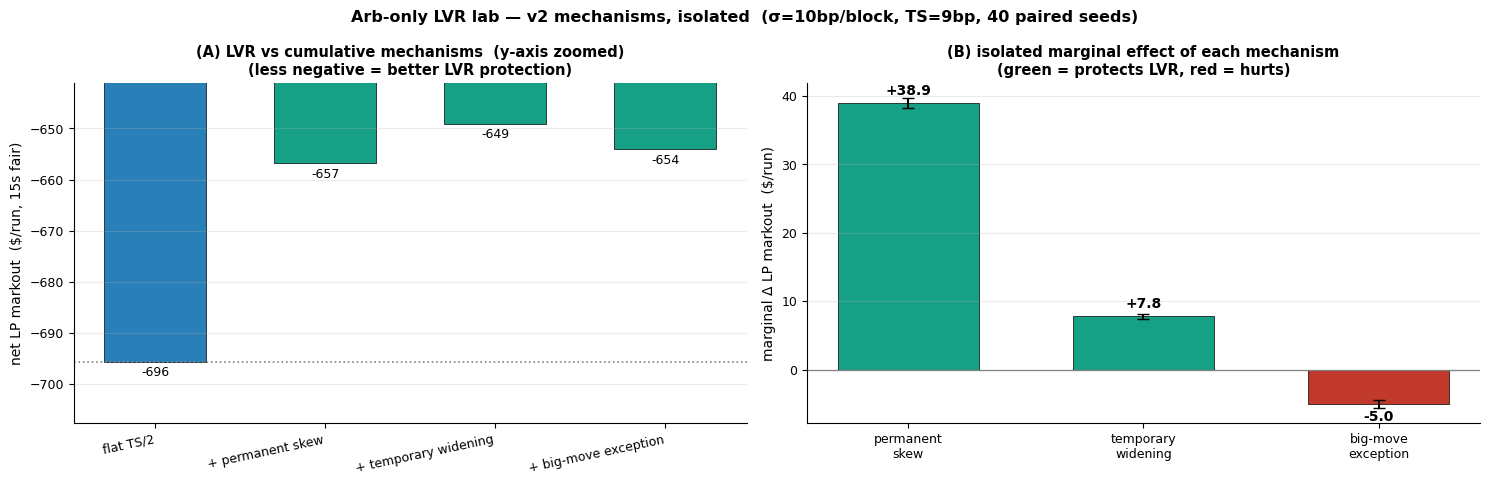

In [2]:
# Mechanism matrix: flat -> +permanent -> +temporary -> +exception, on paired seeds
per = L.run_matrix(seeds=SEEDS, sigma_bps=SIGMA_BPS, ts_bps=TS_BPS)
fig = L.plot_matrix(per)

**Reading.** Each mechanism's *isolated* marginal effect on LVR (panel B):

- **Permanent skew — the workhorse, +&#36;38.9/run** (~5.6% of the −&#36;696 LVR). It leans the fee toward
  the direction of the recent move, which — because arb *direction* is autocorrelated (the stale-mid
  offset, present even under a martingale) — is the direction the next arb most likely takes. The
  common *continuation* arb then pays the higher fee, so the LP captures more of it.
- **Temporary widening — small further gain, +&#36;7.8.** Holding the reverting side up widens the spread
  exactly in the block a move just happened, capturing a bit more on that block's arb.
- **Big-move exception — slightly *hurts* here, −&#36;5.0.** See the vol sweep below: it's a *tail*
  mechanism, and at this σ its 10bp trigger fires on ordinary moves.

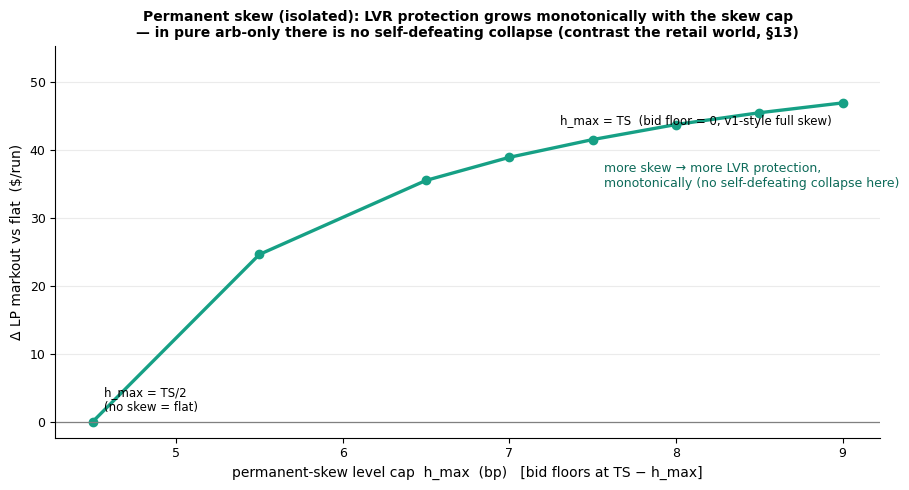

In [3]:
# Permanent skew, isolated: sweep the level cap h_max from TS/2 (no skew) to TS (v1-style full skew)
rows = L.run_hmax_sweep([4.5, 5.5, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0], seeds=SEEDS, sigma_bps=SIGMA_BPS)
fig = L.plot_hmax_sweep(rows)

**Reading — and an important contrast with the retail world.** In pure arb-only, LVR protection grows
**monotonically** with the skew cap: even full skew (`h_max = TS`, bid floor = 0) is best, with arb
count essentially flat. There is **no self-defeating collapse here** (skew lands on the arb's side
~57%; arb-direction persistence ~0.66).

This is the opposite of the realistic simulator (§13 of `realistic_simulator.ipynb`), where aggressive
skew *backfired* — because there the freed (near-zero) side gave away **retail** spread and invited
cheap reversal arbs, collapsing the persistence. Isolating to pure arbitrage shows the skew's effect is
cleanly positive; the self-defeating behaviour is a **retail-interaction** effect, not intrinsic to the
skew. (v2's `h_max` cap is the safeguard that keeps it out of that regime once retail is present.)

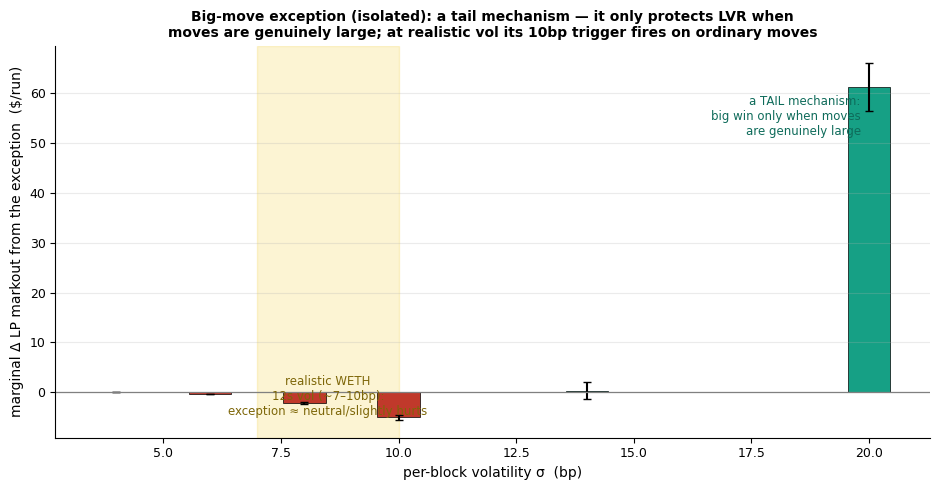

In [4]:
# Big-move exception, isolated: its marginal effect vs per-block volatility
vol = L.run_vol_sweep([4, 6, 8, 10, 14, 20], seeds=SEEDS, ts_bps=TS_BPS)
fig = L.plot_exception_vol(vol)

**Reading.** The exception is a **tail mechanism**. Its `½·PI` widening only pays off when moves are
genuinely large: it's a big win at high σ (≈ +&#36;60/run at σ=20bp) but **neutral-to-slightly-negative**
at realistic WETH 12s vol (~7–10bp), where its fixed 10bp trigger fires on *ordinary* moves and mostly
deters the (rare) corrective reversal arb — leaving stale inventory that marks against the LP over the
15s horizon. So whether it helps is entirely a question of cutoff-vs-volatility calibration.

## Synthesis

Isolated in a clean arb-only world (martingale price, 15s-fair LVR):

| mechanism | marginal effect | why |
|---|---|---|
| **permanent skew** | **+&#36;38.9** (workhorse) | leans the fee toward the autocorrelated arb direction → the common continuation arb pays more |
| **temporary widening** | +&#36;7.8 | widens the spread in the block a move just happened |
| **big-move exception** | −&#36;5.0 here (tail) | only protects LVR when moves are genuinely large; mistuned at this σ |

The directional **permanent skew** is where almost all of v2's LVR protection comes from, and — unlike
the retail world — it does not self-defeat when pushed, because there is no retail to give away on the
de-loaded side. The temporary widening is a small genuine add; the big-move exception is a
volatility-tail tool whose value depends entirely on its cutoff relative to realized vol.